In [100]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


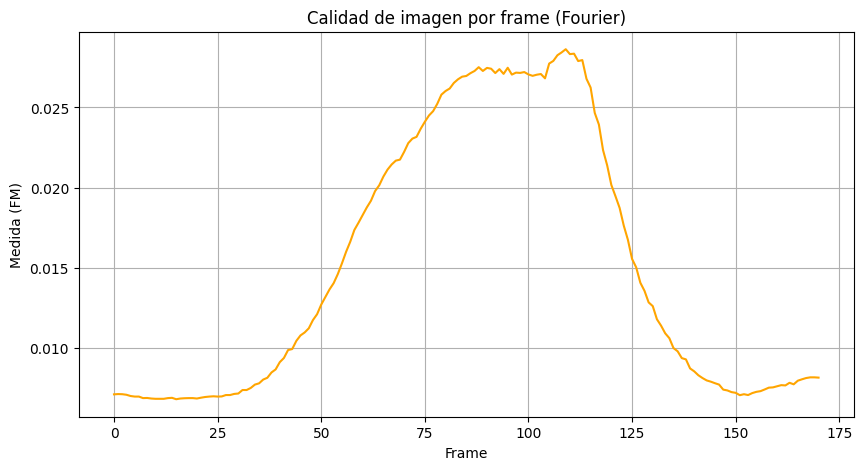

In [110]:

def ImageQualityBlur(img):
    total_number_pixel = img.size

    f = np.fft.fft2(img) #Fourier transformación
    fshift = np.fft.fftshift(f) #shift el origen al centro

    AF = np.abs(fshift)

    M = np.max(AF)
    thres = M / 1000
    h = np.sum(AF > thres)

    FM = h / total_number_pixel

    return FM

cap = cv2.VideoCapture("focus_video.mov")
#i=0

medidas=[]
  
while True:
    ret, frame = cap.read()
    if not ret:
        break
     #print("Frame -> ",i," ",frame)
     #i=i+1
     # Convertir a escala de grises
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray_med= ImageQualityBlur(gray)
    medidas.append(gray_med)

#print("MEDIDAS j =>>",medidas)
plt.figure(figsize=(10,5))

plt.plot(medidas,color="orange")
plt.title("Calidad de imagen por frame (Fourier)")
plt.xlabel("Frame")
plt.ylabel("Medida (FM)")

plt.grid()
#plt.show()f')        
plt.show()

cap.release()
#cv2.destroyAllWindows()

In [66]:
def ImageQualityBlur_ROI(img, roi_ratio=0.1):
    h, w = img.shape

    # calcular tamaño ROI (cuadrado proporcional)
    roi_h = int(h * np.sqrt(roi_ratio))
    roi_w = int(w * np.sqrt(roi_ratio))

    cy, cx = h // 2, w // 2

    roi = img[
        cy - roi_h//2 : cy + roi_h//2,
        cx - roi_w//2 : cx + roi_w//2
    ]

    # FFT sobre ROI
    f = np.fft.fft2(roi)
    fshift = np.fft.fftshift(f)
    AF = np.abs(fshift)

    M = np.max(AF)
    thres = M / 1000

    h_val = np.sum(AF > thres)

    FM = h_val / AF.size

    return FM

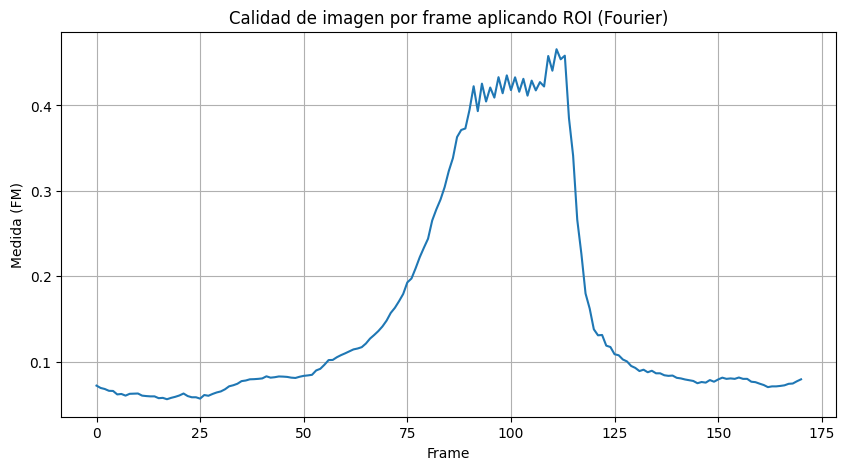

In [108]:

cap = cv2.VideoCapture("focus_video.mov")
medidas_ROI=[]
while True:
    ret, frame = cap.read()
    if not ret:
        break
     #print("Frame -> ",i," ",frame)
     #i=i+1
     # Convertir a escala de grises
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray_med= ImageQualityBlur_ROI(gray,0.05)
    medidas_ROI.append(gray_med)

#print("MEDIDAS j =>>",medidas)
plt.figure(figsize=(10,5))

plt.plot(medidas_ROI)
plt.title("Calidad de imagen por frame aplicando ROI (Fourier)")
plt.xlabel("Frame")
plt.ylabel("Medida (FM)")

plt.grid()
#plt.show()f')        
plt.show()


cap.release()
#v2.destroyAllWindows()

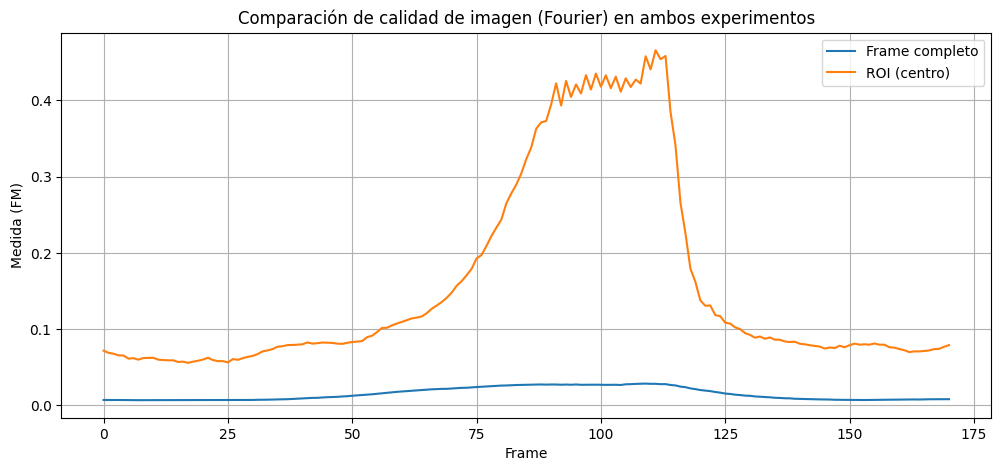

In [71]:
plt.figure(figsize=(12,5))

plt.plot(medidas, label="Frame completo")
plt.plot(medidas_ROI, label="ROI (centro)")

plt.title("Comparación de calidad de imagen (Fourier) en ambos experimentos")
plt.xlabel("Frame")
plt.ylabel("Medida (FM)")

plt.legend()
plt.grid()

plt.show()

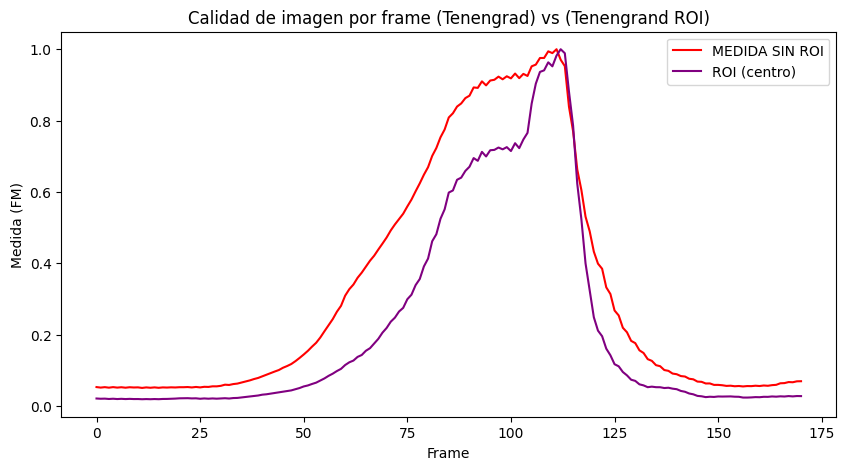

In [105]:
# ¿Por qué se elije este metodo de medición?
def tenengrad(img,roi_c=False,roi_ratio=0.1):
    #roi= img.copy() # creo una copia limpia
    if roi_c :
       # print("Entre al ROI")
        h, w = img.shape
        roi_h = int(h * roi_ratio)
        roi_w = int(w * roi_ratio)
        
        y1 = h // 2 - roi_h // 2
        y2 = h // 2 + roi_h // 2
        x1 = w // 2 - roi_w // 2
        x2 = w // 2 + roi_w // 2
        
        roi = img[y1:y2, x1:x2]
    else:
       # print("NO Entre al ROI")
        roi =img
    # gradientes Sobel
    Gx = cv2.Sobel(roi, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(roi, cv2.CV_64F, 0, 1, ksize=3)

    # magnitud del gradiente
    G = Gx**2 + Gy**2

    # medida final
    FM = np.mean(G)

    return FM

cap = cv2.VideoCapture("focus_video.mov")
#i=0

medidas=[]
medidas_roi=[]  
while True:
    ret, frame = cap.read()
    if not ret:
        break
     #print("Frame -> ",i," ",frame)
     #i=i+1
     # Convertir a escala de grises
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray_med= tenengrad(gray,False,0.1)
    gray_med_roi= tenengrad(gray,True,0.3)
    
    #gray_med_norm = np.array(gray_med) / np.max(gray_med) # normalizamos las medidas  
    #gray_med_roi_norm = np.array(gray_med_roi) / np.max(gray_med_roi) # normalizamos las medidas
    
    medidas.append(gray_med)
    medidas_roi.append(gray_med_roi)

# Normalizamos los datos

medidas = np.array(medidas)
medidas_roi = np.array(medidas_roi)

medidas_norm = medidas / np.max(medidas)
medidas_roi_norm = medidas_roi / np.max(medidas_roi)

#print("MEDIDAS j =>>",medidas_roi)
plt.figure(figsize=(10,5))

plt.plot(medidas_norm,label="MEDIDA SIN ROI",color="red")
plt.plot(medidas_roi_norm, label="ROI (centro)",color="purple")

#plt.plot(medidas,label="MEDIDA SIN ROI ni normalizadas")
#plt.plot(medidas_roi, label="ROI (centro) ni normalizadas")
plt.title("Calidad de imagen por frame (Tenengrad) vs (Tenengrand ROI)")
plt.xlabel("Frame")
plt.ylabel("Medida (FM)")

plt.grid()
#plt.show()f')     
plt.legend()
plt.grid()

plt.show()


cap.release()


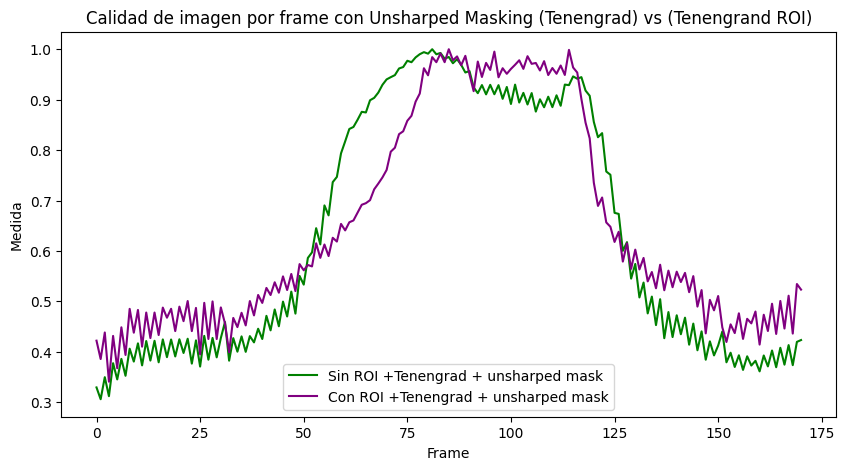

In [106]:
# Si lo realizamos con unsharped mask 
def unsharp_mask(img, kernel_size=(5,5), sigma=1.0, alpha=1.5):
    # blur
    blurred = cv2.GaussianBlur(img, kernel_size, sigma)
    # detalle
    detail = img - blurred
    # sharpen
    sharpened = img + alpha * detail
    # clip para evitar overflow
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return sharpened


cap = cv2.VideoCapture("focus_video.mov")
#i=0

medidas=[]
medidas_roi=[]  
while True:
    ret, frame = cap.read()
    if not ret:
        break
     #print("Frame -> ",i," ",frame)
     #i=i+1
     # Convertir a escala de grises
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # Aplicamos el unsharp mask
    sharp = unsharp_mask(gray, kernel_size=(5,5), sigma=1.0, alpha=1.5)
    gray_med= tenengrad(sharp,False,0.1)
    gray_med_roi= tenengrad(sharp,True,0.3)
       
    medidas.append(gray_med)
    medidas_roi.append(gray_med_roi)

# Normalizamos los datos
medidas = np.array(medidas)
medidas_roi = np.array(medidas_roi)

medidas_norm = medidas / np.max(medidas)
medidas_roi_norm = medidas_roi / np.max(medidas_roi)

plt.figure(figsize=(10,5))

plt.plot(medidas_norm,label="Sin ROI +Tenengrad + unsharped mask",color="green")
plt.plot(medidas_roi_norm, label="Con ROI +Tenengrad + unsharped mask",color="purple")

plt.title("Calidad de imagen por frame con Unsharped Masking (Tenengrad) vs (Tenengrand ROI)")
plt.xlabel("Frame")
plt.ylabel("Medida")

plt.grid()
#plt.show()f')     
plt.legend()
plt.grid()

plt.show()

cap.release()



# Conclusiones y analisis de las graficas obtenidas